In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

# ตั้งค่าการแสดงผลเบื้องต้น
pd.options.display.max_columns = None

In [2]:
# โหลดข้อมูล (จัดการหลักพันที่มีคอมม่า)
file_path = "/Users/hilmanyusoh/Desktop/stock_pattern/data/ข้อมูลย้อนหลังของ ดัชนี SET 100.csv"
df = pd.read_csv(file_path, thousands=',', decimal='.')

# เช็คข้อมูลเบื้องต้น
df.head()

,วันเดือนปี,ล่าสุด,ราคาเปิด,สูงสุด,ต่ำสุด,ปริมาณ,% เปลี่ยน
0,03/13/2026,2000.68,2015.93,2023.86,1992.50,2.92B,-1.49%
1,03/12/2026,2030.92,1981.82,2031.01,1979.86,2.99B,1.81%
2,03/11/2026,1994.77,2005.44,2027.22,1994.77,3.28B,0.05%
3,03/10/2026,1993.83,2002.12,2011.29,1974.74,3.24B,1.57%
4,03/09/2026,1962.94,1904.99,1967.94,1887.28,4.25B,-2.02%


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   วันเดือนปี  3554 non-null   object 
 1   ล่าสุด      3554 non-null   float64
 2   ราคาเปิด    3554 non-null   float64
 3   สูงสุด      3554 non-null   float64
 4   ต่ำสุด      3554 non-null   float64
 5   ปริมาณ      3554 non-null   object 
 6   % เปลี่ยน   3554 non-null   object 
dtypes: float64(4), object(3)
memory usage: 194.5+ KB
None


In [4]:
# คาดการณ์ลำดับ: วันเดือนปี, ล่าสุด, ราคาเปิด, สูงสุด, ต่ำสุด, ปริมาณ, % เปลี่ยน
df.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']
df.head(2)

,Date,Close,Open,High,Low,Volume,Change_Pct
0,03/13/2026,2000.68,2015.93,2023.86,1992.50,2.92B,-1.49%
1,03/12/2026,2030.92,1981.82,2031.01,1979.86,2.99B,1.81%


In [5]:
# แปลงเป็น datetime และเรียงจากเก่าไปใหม่ (สำคัญมากสำหรับ Wyckoff)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,Open,High,Low,Volume,Change_Pct
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1.90M,-0.98%
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2.03M,1.65%
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1.96M,-0.30%
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2.32M,-2.04%
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1.89M,-0.08%


In [6]:
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.upper()
        if 'B' in vol_str: return float(vol_str.replace('B', '')) * 1e9
        if 'M' in vol_str: return float(vol_str.replace('M', '')) * 1e6
        if 'K' in vol_str: return float(vol_str.replace('K', '')) * 1e3
    return vol_str

df['Volume'] = df['Volume'].apply(convert_volume)
df.head()

,Date,Close,Open,High,Low,Volume,Change_Pct
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1900000.0,-0.98%
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2030000.0,1.65%
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1960000.0,-0.30%
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2320000.0,-2.04%
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1890000.0,-0.08%


In [7]:
# เช็คค่าว่าง
print("Missing values:\n", df.isnull().sum())

Missing values:
 Date          0
Close         0
Open          0
High          0
Low           0
Volume        0
Change_Pct    0
dtype: int64


In [8]:
# เช็ค Volume หรือ Price เป็น 0
zero_counts = (df[['Close', 'Volume']] == 0).sum()
print("\nZero values in Close/Volume:\n", zero_counts)


Zero values in Close/Volume:
 Close     0
Volume    0
dtype: int64


In [9]:
# ทำความสะอาด (ลบแถวที่มีปัญหา)
df = df.dropna()
df = df[df['Volume'] > 0]
df.reset_index(drop=True, inplace=True)

In [10]:
# Spread & Close Position
df['Spread'] = df['High'] - df['Low']
df['Close_Pos'] = (df['Close'] - df['Low']) / (df['Spread'] + 1e-6)

# Shadows
df['Lower_Shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)

# Volume Analysis
df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()
df['Rel_Vol'] = df['Volume'] / (df['Vol_MA20'] + 1e-6)

# Price vs Volume Divergence
df['Spread_MA20'] = df['Spread'].rolling(window=20).mean()
df['Rel_Spread'] = df['Spread'] / (df['Spread_MA20'] + 1e-6)

# เทรนราคา (เพื่อแยกฝั่ง Acc/Dist)
df['Price_Trend'] = df['Close'].diff(5)

In [11]:
# หาแนวรับแนวต้านย้อนหลัง 50 แท่ง
window_tr = 50
df['Support_TR'] = df['Low'].rolling(window=window_tr).min().shift(1)
df['Resistance_TR'] = df['High'].rolling(window=window_tr).max().shift(1)

# ระยะห่างจากแนวรับ (%)
df['Dist_from_Sup'] = (df['Low'] - df['Support_TR']) / (df['Support_TR'] + 1e-6)
df['Dist_from_Res'] = (df['High'] - df['Resistance_TR']) / (df['Resistance_TR'] + 1e-6)

In [12]:
df.head()

,Date,Close,Open,High,Low,Volume,Change_Pct,Spread,Close_Pos,Lower_Shadow,Upper_Shadow,Vol_MA20,Rel_Vol,Spread_MA20,Rel_Spread,Price_Trend,Support_TR,Resistance_TR,Dist_from_Sup,Dist_from_Res
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1900000.0,-0.98%,24.10,0.000000,0.00,0.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2030000.0,1.65%,17.90,0.827374,1.99,3.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1960000.0,-0.30%,23.60,0.078390,1.85,6.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2320000.0,-2.04%,22.54,0.223159,5.03,10.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1890000.0,-0.08%,28.32,0.950212,26.91,0.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print("สร้าง Features เรียบร้อยแล้ว! คอลัมน์ที่มีตอนนี้คือ:")
print(df.columns.tolist())

สร้าง Features เรียบร้อยแล้ว! คอลัมน์ที่มีตอนนี้คือ:
['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct', 'Spread', 'Close_Pos', 'Lower_Shadow', 'Upper_Shadow', 'Vol_MA20', 'Rel_Vol', 'Spread_MA20', 'Rel_Spread', 'Price_Trend', 'Support_TR', 'Resistance_TR', 'Dist_from_Sup', 'Dist_from_Res']


In [14]:
# --- Logic: Accumulation (Phase A-E) ที่ปรับปรุงแล้ว --- #

# 1. กำหนดตัวแปรควบคุม (พารามิเตอร์)
THRESHOLD_SC_VOL = 1.3      
THRESHOLD_SOS_VOL = 1.2     
THRESHOLD_SPRING_POS = 0.5  # แข็งแกร่งต้องดึงกลับเกินครึ่งแท่ง
THRESHOLD_LPS_VOL = 0.85    

df['Wyckoff_Event'] = ""
last_sc_idx = -1
has_phase_a = False # ตัวแปรสำคัญ: ป้องกันการจับสัญญาณมั่วก่อนเกิด Selling Climax

# เริ่ม Loop (ใช้ window_tr เพื่อให้แน่ใจว่ามีข้อมูล Support/Resistance แล้ว)
for i in range(window_tr + 1, len(df)):
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    low       = df.loc[i, 'Low']
    high      = df.loc[i, 'High']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']
    dist_sup  = df.loc[i, 'Dist_from_Sup']

    # --- 1. Phase A: หยุดเทรนขาลง (PS & SC) ---
    if rel_vol > THRESHOLD_SC_VOL and trend < 0:
        if close_pos > 0.20:
            df.at[i, 'Wyckoff_Event'] = "SC"
            last_sc_idx = i
            has_phase_a = True # ปลดล็อกให้สามารถหา Event อื่นๆ ในกรอบได้
        else:
            df.at[i, 'Wyckoff_Event'] = "PS"

    # --- 2. Phase B: สร้างกรอบ (AR & ST) - ต้องเกิดหลัง SC ---
    elif has_phase_a and last_sc_idx != -1 and i < last_sc_idx + 20:
        # AR: หาจุดสูงสุดแรกหลัง SC เพื่อตีกรอบ Resistance
        if close > df.loc[i-1, 'Close'] and high == df.loc[last_sc_idx+1:i+1, 'High'].max():
            if "AR" not in df.loc[last_sc_idx:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "AR"
        
        # ST: ลงมาทดสอบแนวรับเดิม (ไม่เกิน 3% จาก Support)
        elif low <= (sup * 1.03) and rel_vol < THRESHOLD_SC_VOL:
            if df.loc[i, 'Wyckoff_Event'] == "":
                df.at[i, 'Wyckoff_Event'] = "ST"

    # --- 3. Phase C: จุดล้างไพ่ (SPRING & TEST) ---
    elif has_phase_a and low < sup:
        # SPRING: หลุดแนวรับแล้วต้องดึงกลับแรงๆ
        if close_pos > THRESHOLD_SPRING_POS:
            df.at[i, 'Wyckoff_Event'] = "SPRING"
        else:
            # ถ้าหลุดแล้วไม่ดึงกลับ นับเป็น Secondary Test (ST) ในโซนต่ำ
            df.at[i, 'Wyckoff_Event'] = "ST"
            
    # TEST: เช็คว่าหลัง SPRING มีแรงขายเหลือไหม (Vol ต้องแห้ง)
    elif has_phase_a and rel_vol < 0.8 and abs(dist_sup) < 0.02:
        if "SPRING" in df.loc[i-30:i, 'Wyckoff_Event'].values:
            df.at[i, 'Wyckoff_Event'] = "TEST"

    # --- 4. Phase D/E: ขาขึ้นยืนยัน (SOS, BU & LPS) ---
    # SOS: ทะลุแนวต้าน Resistance พร้อม Volume ยืนยัน
    elif has_phase_a and close > res and rel_vol > THRESHOLD_SOS_VOL:
        df.at[i, 'Wyckoff_Event'] = "SOS"
        
    # BU (Back Up): การย่อลงมาทดสอบแนวต้านเดิมที่กลายเป็นแนวรับ (S-R Flip)
    elif has_phase_a and "SOS" in df.loc[i-15:i, 'Wyckoff_Event'].values:
        if low >= res * 0.97 and close <= res * 1.05 and close_pos > 0.4:
            if "BU" not in df.loc[i-10:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "BU"

    # LPS: ยก Low ในโซนบน พร้อม Volume ที่ลดลง (Lack of Supply)
    elif has_phase_a and trend > 0 and close_pos > 0.6:
        is_higher_low = low > df.loc[i-15:i, 'Low'].min()
        is_low_vol    = rel_vol < THRESHOLD_LPS_VOL
        is_upper_zone = close > (sup + (res - sup) * 0.6)
        
        if is_higher_low and is_low_vol and is_upper_zone:
            if "LPS" not in df.loc[i-10:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "LPS"

# กรองดูผลลัพธ์
event_list = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']
detected_acc = df[df['Wyckoff_Event'].isin(event_list)]
print(detected_acc[['Date', 'Close', 'Rel_Vol', 'Wyckoff_Event']].tail(10))

           Date    Close   Rel_Vol Wyckoff_Event
3530 2026-02-09  2008.83  2.518741           SOS
3531 2026-02-10  2026.85  1.296667           SOS
3533 2026-02-12  2073.97  1.451943           SOS
3536 2026-02-17  2099.65  1.323764           SOS
3537 2026-02-18  2108.53  1.327892           SOS
3538 2026-02-19  2146.63  1.463264           SOS
3541 2026-02-24  2138.81  1.005140            BU
3545 2026-03-02  2090.76  1.402557            PS
3546 2026-03-04  1975.04  1.800682            SC
3547 2026-03-05  2015.28  1.211195            AR


In [15]:
# --- Logic: Distribution (Phase A-E) ที่ปรับปรุงแล้ว --- #

# 1. กำหนดตัวแปรควบคุม (Parameters)
THRESHOLD_BC_VOL = 1.3       
THRESHOLD_SOW_VOL = 1.2      # ปรับให้สูงขึ้นเพื่อยืนยันแรงเทขายจริง
THRESHOLD_LPSY_VOL = 0.85    # แรงซื้อต้องแห้งจริงๆ

last_bc_idx = -1
has_dist_phase_a = False # ตัวแปรควบคุมลำดับ Phase

for i in range(10, len(df)):
    if df.loc[i, 'Wyckoff_Event'] != "": continue # ข้ามถ้ามี Event ฝั่ง Acc อยู่แล้ว
    
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    high      = df.loc[i, 'High']
    low       = df.loc[i, 'Low']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']

    # 1. Phase A: จุดเริ่มกระจายของ (PSY & BC)
    if rel_vol > THRESHOLD_BC_VOL and trend > 0:
        if close_pos < 0.80: # ปิดต่ำกว่า High แสดงว่ามี Supply กดลงมา
            df.at[i, 'Wyckoff_Event'] = "BC"
            last_bc_idx = i
            has_dist_phase_a = True
        else:
            df.at[i, 'Wyckoff_Event'] = "PSY"

    # 2. Phase B: การตอบโต้และทดสอบ (AR & ST) - ต้องเกิดหลัง BC
    elif has_dist_phase_a and last_bc_idx != -1 and i < last_bc_idx + 20:
        # AR_Dist: จุดต่ำสุดแรกหลัง BC (จุดเริ่มตีกรอบแนวรับ)
        if low == df.loc[last_bc_idx+1:i+1, 'Low'].min() and close < df.loc[i-1, 'Close']:
            if "AR_Dist" not in df.loc[last_bc_idx:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "AR_Dist"
        
        # ST_Dist: การกลับขึ้นไปทดสอบ High เดิมด้วย Volume ที่น้อยลง
        elif high >= (res * 0.97) and rel_vol < THRESHOLD_BC_VOL:
            if df.loc[i, 'Wyckoff_Event'] == "":
                df.at[i, 'Wyckoff_Event'] = "ST_Dist"

    # 3. Phase C: จุดดักเชือด (UT & UTAD)
    # ราคาต้องทะลุแนวต้าน (res) แล้วตบกลับลงมาปิดต่ำ
    elif has_dist_phase_a and high > res:
        if close_pos < 0.4: # หลอกว่า Breakout แล้วดึงกลับแรง
            # ถ้าเกิดหลัง BC นานเกิน 20 วัน ให้เรียก UTAD (Upthrust After Distribution)
            df.at[i, 'Wyckoff_Event'] = "UTAD" if i > last_bc_idx + 20 else "UT"

    # 4. Phase D/E: ยืนยันขาลง (SOW & LPSY)
    # SOW: หลุดแนวรับ (sup) พร้อม Volume ที่เพิ่มขึ้น
    elif has_dist_phase_a and close < sup and rel_vol > THRESHOLD_SOW_VOL:
        df.at[i, 'Wyckoff_Event'] = "SOW"

    # LPSY: เด้งขึ้นมาสั้นๆ ในโซนล่างเพื่อทำ Lower High พร้อม Vol แห้ง
    elif has_dist_phase_a and trend < 0 and close_pos < 0.4:
        is_lower_high = high < df.loc[i-15:i, 'High'].max()
        is_low_vol    = rel_vol < THRESHOLD_LPSY_VOL
        is_lower_zone = close < (sup + (res - sup) * 0.4) # อยู่ในโซนล่างของกรอบ
        
        if is_lower_high and is_low_vol and is_lower_zone:
            if "LPSY" not in df.loc[i-10:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "LPSY"
# ดูผลลัพธ์ Distribution
dist_list = ['PSY', 'BC', 'AR_Dist', 'ST_Dist', 'UT', 'UTAD', 'SOW', 'LPSY']
df[df['Wyckoff_Event'].isin(dist_list)].tail(10)

,Date,Close,Open,High,Low,Volume,Change_Pct,Spread,Close_Pos,Lower_Shadow,Upper_Shadow,Vol_MA20,Rel_Vol,Spread_MA20,Rel_Spread,Price_Trend,Support_TR,Resistance_TR,Dist_from_Sup,Dist_from_Res,Wyckoff_Event
3529,2026-02-06,1938.21,1922.74,1951.42,1921.13,1.940000e+09,0.57%,30.29,0.563882,1.61,13.21,2.429500e+09,0.798518,25.5820,1.184036,53.76,1745.35,1936.29,0.100713,0.007814,ST_Dist
3532,2026-02-11,2026.44,2027.87,2038.17,2020.81,3.380000e+09,-0.02%,17.36,0.324309,5.63,10.30,2.829500e+09,1.194557,25.4415,0.682350,100.69,1753.30,2029.38,0.152575,0.004331,ST_Dist
3534,2026-02-13,2059.83,2066.31,2079.41,2052.48,4.190000e+09,-0.68%,26.93,0.272930,7.35,13.10,3.024000e+09,1.385582,25.6310,1.050681,121.62,1753.30,2073.97,0.170638,0.002623,BC
3535,2026-02-16,2068.66,2075.25,2084.68,2061.35,3.060000e+09,0.43%,23.33,0.313330,7.31,9.43,3.065000e+09,0.998369,25.6190,0.910652,59.83,1757.31,2079.41,0.173014,0.002534,ST_Dist
3539,2026-02-20,2126.50,2143.23,2148.01,2117.21,5.110000e+09,-0.94%,30.80,0.301623,9.29,4.78,3.343000e+09,1.528567,25.9160,1.188455,66.67,1757.31,2149.64,0.204802,-0.000758,BC
3540,2026-02-23,2121.19,2137.12,2157.10,2103.06,4.630000e+09,-0.25%,54.04,0.335492,18.13,19.98,3.451500e+09,1.341446,27.8485,1.940499,52.53,1757.31,2149.64,0.196750,0.003470,BC
3542,2026-02-25,2172.74,2161.53,2183.43,2155.90,3.980000e+09,1.59%,27.53,0.611696,5.63,10.69,3.584000e+09,1.110491,28.5100,0.965626,64.21,1757.31,2157.10,0.226818,0.012206,ST_Dist
3543,2026-02-26,2194.96,2186.40,2198.56,2175.39,3.170000e+09,1.02%,23.17,0.844627,11.01,3.60,3.623500e+09,0.874845,28.5295,0.812142,48.33,1757.31,2183.43,0.237909,0.006929,ST_Dist
3544,2026-02-27,2182.04,2177.08,2209.50,2173.40,3.900000e+09,-0.59%,36.10,0.239335,3.68,27.46,3.705500e+09,1.052490,29.6090,1.219224,55.54,1757.31,2198.56,0.236777,0.004976,ST_Dist
3549,2026-03-09,1962.94,1904.99,1967.94,1887.28,4.250000e+09,-2.02%,80.66,0.938011,17.71,5.00,4.380000e+09,0.970320,40.0350,2.014737,-219.10,1757.31,2209.50,0.073960,-0.109328,AR_Dist


In [16]:
detected = df[df['Wyckoff_Event'] != ""].copy()

# ตรวจสอบว่าคอลัมน์ Date เป็น datetime หรือไม่ (กัน Error .dt.days)
if not pd.api.types.is_datetime64_any_dtype(df.index):
    detected['Date_Col'] = pd.to_datetime(detected.index)
else:
    detected['Date_Col'] = detected.index

# คำนวณระยะห่างระหว่าง Event (วัน)
detected['Days_Since_Last'] = detected['Date_Col'].diff().dt.days

In [17]:
# --- 2. ส่วนของ Accumulation Summary ---
acc_list = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']
acc_stats = detected[detected['Wyckoff_Event'].isin(acc_list)].copy()

print("=== [COUNT] Accumulation Summary ===")
if not acc_stats.empty:
    print(acc_stats['Wyckoff_Event'].value_counts().sort_index())
    print(f"\nTotal Acc Events: {len(acc_stats)}")
else:
    print("No Accumulation events found.")

=== [COUNT] Accumulation Summary ===
Wyckoff_Event
AR         57
BU         37
LPS        39
PS         73
SC        119
SOS        61
SPRING     21
ST        556
TEST       18
Name: count, dtype: int64

Total Acc Events: 981


In [18]:
# --- 3. ส่วนของ Distribution Summary ---
dist_list = ['PSY', 'BC', 'AR_Dist', 'ST_Dist', 'UT', 'UTAD', 'SOW', 'LPSY']
dist_stats = detected[detected['Wyckoff_Event'].isin(dist_list)].copy()

print("=== [COUNT] Distribution Summary ===")
if not dist_stats.empty:
    print(dist_stats['Wyckoff_Event'].value_counts().sort_index())
    print(f"\nTotal Dist Events: {len(dist_stats)}")
else:
    print("No Distribution events found.")

=== [COUNT] Distribution Summary ===
Wyckoff_Event
AR_Dist     58
BC         161
LPSY        23
PSY         65
ST_Dist    781
UT           1
UTAD        28
Name: count, dtype: int64

Total Dist Events: 1117


In [19]:
# 3. สรุปผลแยกตาม Event Type
print("=== Event Summary Statistics ===")
print(detected['Wyckoff_Event'].value_counts())

=== Event Summary Statistics ===
Wyckoff_Event
ST_Dist    781
ST         556
BC         161
SC         119
PS          73
PSY         65
SOS         61
AR_Dist     58
AR          57
LPS         39
BU          37
UTAD        28
LPSY        23
SPRING      21
TEST        18
UT           1
Name: count, dtype: int64


In [20]:
# 4. แสดง 15 เหตุการณ์ล่าสุด
print("\n=== Latest 15 Events ===")
print(detected[['Date', 'Close', 'Rel_Vol', 'Close_Pos', 'Wyckoff_Event']].tail(15))

# เช็คผลตอบแทนหลังเกิด SPRING (Phase C) ภายใน 10 วัน
spring_idxs = df[df['Wyckoff_Event'] == "SPRING"].index
if len(spring_idxs) > 0:
    results = []
    for idx in spring_idxs:
        current_idx = df.index.get_loc(idx)
        if current_idx + 10 < len(df):
            ret = (df.iloc[current_idx + 10]['Close'] - df.iloc[current_idx]['Close']) / df.iloc[current_idx]['Close']
            results.append(ret > 0)
    
    if results:
        win_rate = (sum(results) / len(results)) * 100
        print(f"Spring Win Rate (Price up in 10 days): {win_rate:.2f}% (from {len(results)} events)")
else:
    print("No SPRING events to calculate Win Rate.")


=== Latest 15 Events ===
           Date    Close   Rel_Vol  Close_Pos Wyckoff_Event
3534 2026-02-13  2059.83  1.385582   0.272930            BC
3535 2026-02-16  2068.66  0.998369   0.313330       ST_Dist
3536 2026-02-17  2099.65  1.323764   0.954055           SOS
3537 2026-02-18  2108.53  1.327892   0.728141           SOS
3538 2026-02-19  2146.63  1.463264   0.914900           SOS
3539 2026-02-20  2126.50  1.528567   0.301623            BC
3540 2026-02-23  2121.19  1.341446   0.335492            BC
3541 2026-02-24  2138.81  1.005140   0.916584            BU
3542 2026-02-25  2172.74  1.110491   0.611696       ST_Dist
3543 2026-02-26  2194.96  0.874845   0.844627       ST_Dist
3544 2026-02-27  2182.04  1.052490   0.239335       ST_Dist
3545 2026-03-02  2090.76  1.402557   0.000000            PS
3546 2026-03-04  1975.04  1.800682   0.725949            SC
3547 2026-03-05  2015.28  1.211195   0.681629            AR
3549 2026-03-09  1962.94  0.970320   0.938011       AR_Dist
Spring Win Rat

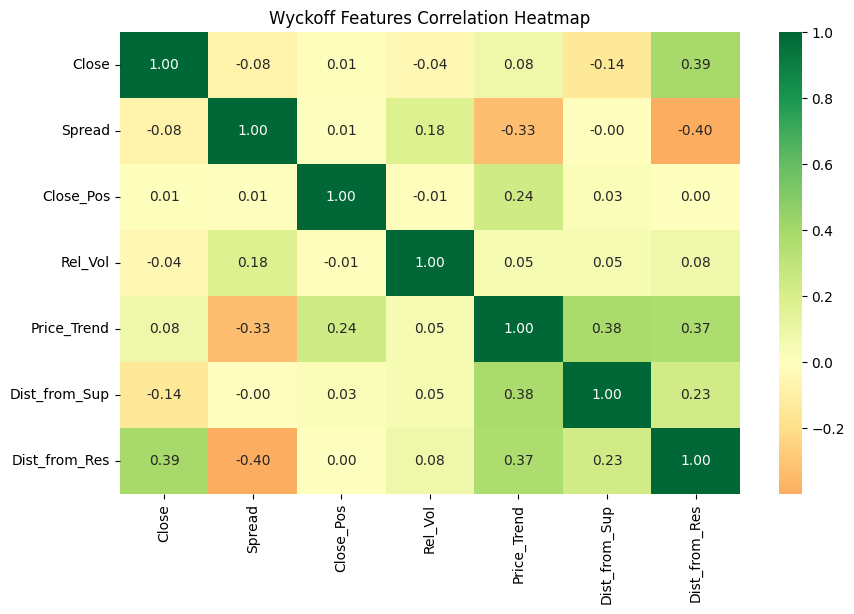

In [21]:
plt.figure(figsize=(10, 6))
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขและมีนัยสำคัญต่อ Wyckoff
feat_cols = ['Close', 'Spread', 'Close_Pos', 'Rel_Vol', 'Price_Trend', 'Dist_from_Sup', 'Dist_from_Res']
sns.heatmap(df[feat_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title("Wyckoff Features Correlation Heatmap")
plt.show()

In [24]:
# กรองเฉพาะ Event ฝั่งสะสม
acc_list = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']
df_acc = df[df['Wyckoff_Event'].isin(acc_list)].copy()

print("=== Wyckoff Accumulation Summary Table ===")
df_acc[['Close', 'Rel_Vol', 'Close_Pos','Wyckoff_Event', 'Support_TR', 'Resistance_TR']].tail(20)

=== Wyckoff Accumulation Summary Table ===


,Close,Rel_Vol,Close_Pos,Wyckoff_Event,Support_TR,Resistance_TR
3402,1745.18,1.219563,0.618139,BU,1457.95,1749.73
3406,1766.86,1.415059,0.797366,SOS,1457.95,1764.96
3416,1755.44,0.718262,0.593811,BU,1457.95,1793.09
3432,1809.01,0.796312,0.928945,LPS,1506.92,1811.64
3459,1839.83,1.270678,0.549798,SOS,1711.65,1835.36
3479,1754.16,1.199504,0.264326,ST,1765.60,1880.65
3482,1767.32,1.376124,0.179053,PS,1745.35,1880.65
3516,1857.06,1.485566,0.585843,SOS,1745.35,1845.16
3517,1883.75,1.679142,0.829303,SOS,1745.35,1870.81
3520,1862.92,1.160571,0.465887,BU,1745.35,1895.89


In [25]:
# กรองเฉพาะ Event ฝั่งระบายของ
dist_list = ['PSY', 'BC', 'AR_Dist', 'ST', 'UT', 'UTAD', 'SOW', 'LPSY']
df_dist = df[df['Wyckoff_Event'].isin(dist_list)].copy()

print("=== Wyckoff Distribution Summary Table ===")
df_dist[['Close', 'Rel_Vol', 'Close_Pos','Wyckoff_Event', 'Support_TR', 'Resistance_TR']].tail(20)

=== Wyckoff Distribution Summary Table ===


,Close,Rel_Vol,Close_Pos,Wyckoff_Event,Support_TR,Resistance_TR
3407,1768.58,1.335040,0.231179,BC,1457.95,1771.63
3408,1754.39,1.001795,0.429764,AR_Dist,1457.95,1793.09
3431,1801.11,0.788756,0.375445,UTAD,1498.22,1800.48
3434,1819.46,1.302326,0.320705,BC,1533.98,1824.26
3452,1766.34,1.021469,0.000000,AR_Dist,1698.68,1829.94
3460,1847.58,1.211548,0.032192,UTAD,1711.65,1850.95
3463,1834.69,1.324042,0.695498,BC,1711.65,1880.65
3467,1804.47,0.910983,0.627476,AR_Dist,1722.01,1880.65
3479,1754.16,1.199504,0.264326,ST,1765.60,1880.65
3483,1756.08,0.744467,0.124597,LPSY,1745.35,1880.65


In [32]:
# 1. ตั้งค่าจำนวนวันที่ต้องการดู
n = 10 
recent_df = df.tail(n).copy()

# 2. แสดงเฉพาะวันที่พบ Wyckoff Event (ถ้าไม่มีจะแจ้งเตือน)
found = recent_df[recent_df['Wyckoff_Event'] != ""]

print(f"=== Wyckoff Events Found (Last {n} Days) ===")
if not found.empty:
    print(found[['Date', 'Close', 'Wyckoff_Event', 'Rel_Vol']].to_string(index=False))
else:
    print("No events detected in this period.")

# 3. แสดง Timeline ภาพรวม (แบบสั้นๆ 10 แถวท้ายสุด)
print(recent_df[['Date', 'Close', 'Wyckoff_Event']].tail(10).to_string(index=False))

=== Wyckoff Events Found (Last 10 Days) ===
      Date   Close Wyckoff_Event  Rel_Vol
2026-02-27 2182.04       ST_Dist 1.052490
2026-03-02 2090.76            PS 1.402557
2026-03-04 1975.04            SC 1.800682
2026-03-05 2015.28            AR 1.211195
2026-03-09 1962.94       AR_Dist 0.970320
      Date   Close Wyckoff_Event
2026-02-27 2182.04       ST_Dist
2026-03-02 2090.76            PS
2026-03-04 1975.04            SC
2026-03-05 2015.28            AR
2026-03-06 2003.47              
2026-03-09 1962.94       AR_Dist
2026-03-10 1993.83              
2026-03-11 1994.77              
2026-03-12 2030.92              
2026-03-13 2000.68              


In [ ]:
# --- Visualization: Full Accumulation Phase A-E (Updated) --- #

# 1. กำหนดรายชื่อ Event ให้ครอบคลุม Logic ใหม่
acc_events = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU', 'SOW_In_TR']

# 2. ใช้ช่วงข้อมูลที่เหมาะสม (1000 วันถือว่าเห็นภาพกว้างได้ดีมาก)
dfpl = df.tail(1000).copy() 

# 3. สร้าง Figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05, 
                    row_heights=[0.7, 0.3],
                    subplot_titles=('SET 100 Wyckoff Accumulation: Phase A-E Analysis', 'Volume Analysis'))

# --- กราฟบน: Candlestick & TR Lines ---
# ใช้ x=dfpl.index เพื่อให้ตรงกับตำแหน่งใน DataFrame
fig.add_trace(go.Candlestick(x=dfpl.index, open=dfpl['Open'], high=dfpl['High'], 
                             low=dfpl['Low'], close=dfpl['Close'], name='Price'), row=1, col=1)

# เส้น Trading Range (Dynamic Support/Resistance)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Support_TR'], 
                         line=dict(color='rgba(255, 100, 100, 0.5)', dash='dash'), name='Support Line'), row=1, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Resistance_TR'], 
                         line=dict(color='rgba(100, 255, 100, 0.5)', dash='dash'), name='Resistance Line'), row=1, col=1)

# 4. การจัดการ Annotations (แยกสีตามกลุ่มความสำคัญ)
event_df = dfpl[dfpl['Wyckoff_Event'].isin(acc_events)]

for idx, row in event_df.iterrows():
    e_name = row['Wyckoff_Event']
    
    # กำหนดสีตาม Phase
    if e_name in ['SC', 'SPRING']: 
        bg_color = "#FF00FF" # ชมพู: จุดกลับตัวสำคัญ (Phase A/C)
    elif e_name in ['SOS', 'BU', 'LPS']: 
        bg_color = "#00FF00" # เขียว: ยืนยันขาขึ้น (Phase D/E)
    elif e_name == 'SOW_In_TR':
        bg_color = "#FF4500" # ส้มแดง: สัญญาณเตือนว่าอาจจะไม่ใช่ Acc
    else:
        bg_color = "#1f77b4" # น้ำเงิน: จุดทดสอบและสร้างฐาน (Phase B)
    
    # กำหนดตำแหน่งวาง Label (สลับบน-ล่างเพื่อไม่ให้บังแท่งเทียน)
    # กลุ่มที่มักอยู่ด้านบน: AR, SOS, BU
    is_high_label = e_name in ['AR', 'SOS', 'BU', 'PS']
    y_pos = row['High'] if is_high_label else row['Low']
    ay_val = -60 if is_high_label else 60 # ระยะห่างของลูกศร
    
    fig.add_annotation(
        x=idx, y=y_pos, text=f"<b>{e_name}</b>",
        showarrow=True, arrowhead=2, arrowcolor="white",
        ax=0, ay=ay_val, bgcolor=bg_color,
        font=dict(color="white" if bg_color != "#00FF00" else "black", size=10),
        opacity=0.9
    )

# --- กราฟล่าง: Volume & Climax ---
vol_colors = ['#26a69a' if c >= o else '#ef5350' for c, o in zip(dfpl['Close'], dfpl['Open'])]
fig.add_trace(go.Bar(x=dfpl.index, y=dfpl['Volume'], name='Volume', marker_color=vol_colors, opacity=0.5), row=2, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Vol_MA20'], line=dict(color='yellow', width=1.5), name='Vol MA20'), row=2, col=1)

# ปรับ Layout ให้สวยงามและใช้งานง่าย
fig.update_layout(
    height=1000, 
    template='plotly_dark', 
    xaxis_rangeslider_visible=False,
    margin=dict(l=50, r=50, t=80, b=50)
)

# ปรับแกน X ให้แสดงวันที่สวยงาม (ถ้า Index เป็น Datetime)
fig.update_xaxes(title_text="Timeline", row=2, col=1)
fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)

fig.show()

In [ ]:
# --- Visualization: Full Distribution Phase A-E (Updated) --- #

# 1. รายชื่อ Event ฝั่ง Distribution ให้ครบตาม Logic ใหม่
dist_events = ['PSY', 'BC', 'AR_Dist', 'ST_Dist', 'UT', 'UTAD', 'SOW', 'LPSY']

# 2. ขยายช่วงข้อมูลเป็น 700-1000 วัน เพื่อให้เห็นรอบการแจกจ่ายที่ชัดเจน
dfpl = df.tail(1000).copy()

# 3. สร้าง Figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05, 
                    row_heights=[0.7, 0.3], 
                    subplot_titles=('SET 100 Wyckoff Distribution: Phase A-E Analysis', 'Volume Analysis'))

# --- กราฟบน: ราคา และ Trading Range ---
fig.add_trace(go.Candlestick(x=dfpl.index, open=dfpl['Open'], high=dfpl['High'], 
                             low=dfpl['Low'], close=dfpl['Close'], name='Price'), row=1, col=1)

# เส้นแนวรับ-แนวต้าน (Trading Range boundaries)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Support_TR'], 
                         line=dict(color='rgba(255, 100, 100, 0.5)', dash='dash'), 
                         name='Support (Ice)'), row=1, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Resistance_TR'], 
                         line=dict(color='rgba(100, 255, 100, 0.5)', dash='dash'), 
                         name='Resistance (Creek)'), row=1, col=1)

# กรอง Event
event_df = dfpl[dfpl['Wyckoff_Event'].isin(dist_events)]

# 4. เพิ่ม Annotations แยกสีตาม "ระดับความอันตราย"
for idx, row in event_df.iterrows():
    e_name = row['Wyckoff_Event']
    
    # กำหนดสีตามความสำคัญ
    if e_name in ['UTAD', 'SOW']:
        bg_color = "#FF0000"   # แดงสด: จุดเปลี่ยนเทรนสำคัญ (Phase C/D)
    elif e_name in ['BC', 'LPSY']:
        bg_color = "#FF8C00"   # ส้มเข้ม: จุดที่แรงซื้อเริ่มหมด (Phase A/D)
    elif e_name == 'UT':
        bg_color = "#B22222"   # แดงเข้ม: จุดทดสอบแรงขายด้านบน
    else:
        bg_color = "#FFA500"   # ส้มมาตรฐาน: จุดเริ่มสร้างกรอบ (Phase A/B)
    
    # กำหนดตำแหน่งการวาง (สลับ บน-ล่าง)
    # จุดที่เกิดบริเวณแนวต้าน (ด้านบน): PSY, BC, ST_Dist, UT, UTAD
    is_top_zone = e_name in ['PSY', 'BC', 'ST_Dist', 'UT', 'UTAD']
    y_pos = row['High'] if is_top_zone else row['Low']
    ay_val = -60 if is_top_zone else 60
    
    fig.add_annotation(
        x=idx, y=y_pos,
        text=f"<b>{e_name}</b>",
        showarrow=True, arrowhead=2, arrowcolor="white",
        ax=0, ay=ay_val,
        bgcolor=bg_color,
        font=dict(color="white", size=10),
        bordercolor="white",
        opacity=0.9
    )

# --- กราฟล่าง: Volume Analysis ---
vol_colors = ['#26a69a' if c >= o else '#ef5350' for c, o in zip(dfpl['Close'], dfpl['Open'])]
fig.add_trace(go.Bar(x=dfpl.index, y=dfpl['Volume'], name='Volume', 
                     marker_color=vol_colors, opacity=0.5), row=2, col=1)

fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Vol_MA20'], 
                         line=dict(color='yellow', width=1.5), name='Vol MA20'), row=2, col=1)

# ปรับแต่ง Layout ให้สอดคล้องกับฝั่ง Accumulation
fig.update_layout(
    height=1000,
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    margin=dict(l=50, r=50, t=80, b=50),
    showlegend=True
)

fig.show()